In [1]:
import pandas as pd
import numpy as np
# === Load CSV ===
df = pd.read_csv("/home/gzu5140/Keerthana_b1042/grnInference/plot_data/parameter_scan/A_to_B_inference_results.csv", index_col=0)
df['ratio'] = df['k_add_gene_1_to_gene_2']/df['k_on']

In [2]:
df

,param_index,corr_gene_gene_gene_1_mRNA_gene_1_mRNA_t1_t20,pval_gene_gene_gene_1_mRNA_gene_1_mRNA_t1_t20,corr_gene_gene_gene_1_mRNA_gene_2_mRNA_t1_t20,pval_gene_gene_gene_1_mRNA_gene_2_mRNA_t1_t20,corr_gene_gene_gene_2_mRNA_gene_2_mRNA_t1_t20,pval_gene_gene_gene_2_mRNA_gene_2_mRNA_t1_t20,zscore_twin_vs_random_gene_1_mRNA_gene_2_mRNA_t1,twin_corr_gene_1_mRNA_gene_2_mRNA_t1,pval_twin_vs_random_gene_1_mRNA_gene_2_mRNA_t1,...,k_add_gene_1_to_gene_2,n_gene_2_to_gene_1,k_add_gene_2_to_gene_1,n_gene_1_to_gene_3,k_add_gene_1_to_gene_3,n_gene_2_to_gene_3,k_add_gene_2_to_gene_3,pair_id,gene_id,ratio
0,12075_12076,1.0,0.0,0.013291,0.1438,1.0,0.0,-2.614784,-0.010124,0.6664,...,1.282811,0.113327,5.889337,0.514012,0.180087,0.619391,2.251425,4025,1,0.797848
1,12075_12076,1.0,0.0,0.013291,0.1438,1.0,0.0,-2.614784,-0.010124,0.6664,...,1.282811,0.113327,5.889337,0.514012,0.180087,0.619391,2.251425,4025,2,1.664498
2,10317_10318,1.0,0.0,0.003548,0.7004,1.0,0.0,3.161168,0.030695,0.0012,...,0.039139,2.789532,1.072685,0.410195,0.024726,0.558148,0.009765,3439,1,0.207439
3,10317_10318,1.0,0.0,0.003548,0.7004,1.0,0.0,3.161168,0.030695,0.0012,...,0.039139,2.789532,1.072685,0.410195,0.024726,0.558148,0.009765,3439,2,0.587124
4,67632_67633,1.0,0.0,0.032766,0.0001,1.0,0.0,-3.919104,-0.002176,0.9999,...,0.209335,1.602428,0.040871,0.553356,4.210279,1.833233,19.349386,22544,1,13.466760
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
49973,48405_48406,1.0,0.0,0.007664,0.4042,1.0,0.0,-4.817252,-0.037326,0.0005,...,0.113150,2.841398,0.343124,4.441042,1.307223,0.487127,5.870099,16135,2,1.211410
49974,67812_67813,1.0,0.0,0.017491,0.0555,1.0,0.0,-1.893770,-0.001998,0.9584,...,0.075509,4.525105,0.071702,1.081779,5.333053,0.806969,3.764559,22604,1,1.070231
49975,67812_67813,1.0,0.0,0.017491,0.0555,1.0,0.0,-1.893770,-0.001998,0.9584,...,0.075509,4.525105,0.071702,1.081779,5.333053,0.806969,3.764559,22604,2,4.418000
49976,22413_22414,1.0,0.0,0.049939,0.0000,1.0,0.0,-5.470835,-0.007568,0.9998,...,5.764065,2.200468,0.220269,0.668672,1.085234,0.391012,0.342518,7471,1,74.768954


In [5]:

# --- parameter columns ---
gene_specific = [
    "k_on", "k_off", "mrna_half_life", "protein_half_life",
    "k_prod_mRNA", "k_prod_protein", "pi_on", "ratio"
]
pair_specific = [
    "k_add_gene_1_to_gene_2", "n_gene_1_to_gene_2"
]

# Split into gene 1 and gene 2
g1 = df[df["gene_id"] == 1][["pair_id"] + gene_specific + pair_specific].copy()
g2 = df[df["gene_id"] == 2][["pair_id"] + gene_specific].copy()

# Rename columns for clarity
g1 = g1.rename(columns={c: f"{c}_g1" for c in gene_specific})
g2 = g2.rename(columns={c: f"{c}_g2" for c in gene_specific})

# Merge by pair_id
merged = pd.merge(g1, g2, on="pair_id", suffixes=("", "_drop"))
merged = merged[[c for c in merged.columns if not c.endswith("_drop")]]  # clean duplicates

# --- keep shared parameters only once ---
merged = merged.loc[:, ~merged.columns.duplicated()]

# Example label: significant if directed p-value < 0.01
pvals = (
    df[df["gene_id"] == 1][["pair_id", "corr_gene_gene_gene_1_mRNA_gene_2_mRNA_t1_t20"]]
    .drop_duplicates("pair_id")
)
merged = merged.merge(pvals, on="pair_id", how="left")
merged["significant"] = (merged["corr_gene_gene_gene_1_mRNA_gene_2_mRNA_t1_t20"] < 0.01).astype(int)


In [6]:
import xgboost as xgb
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report

X = merged.drop(columns=["pair_id", "significant", "corr_gene_gene_gene_1_mRNA_gene_2_mRNA_t1_t20", "ratio_g1"])
y = merged["significant"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

model = xgb.XGBClassifier(
    n_estimators=200,
    max_depth=4,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42,
    eval_metric="logloss"
)
model.fit(X_train, y_train)

print(classification_report(y_test, model.predict(X_test)))


              precision    recall  f1-score   support

           0       0.80      0.78      0.79      2579
           1       0.77      0.80      0.78      2420

    accuracy                           0.79      4999
   macro avg       0.79      0.79      0.79      4999
weighted avg       0.79      0.79      0.79      4999



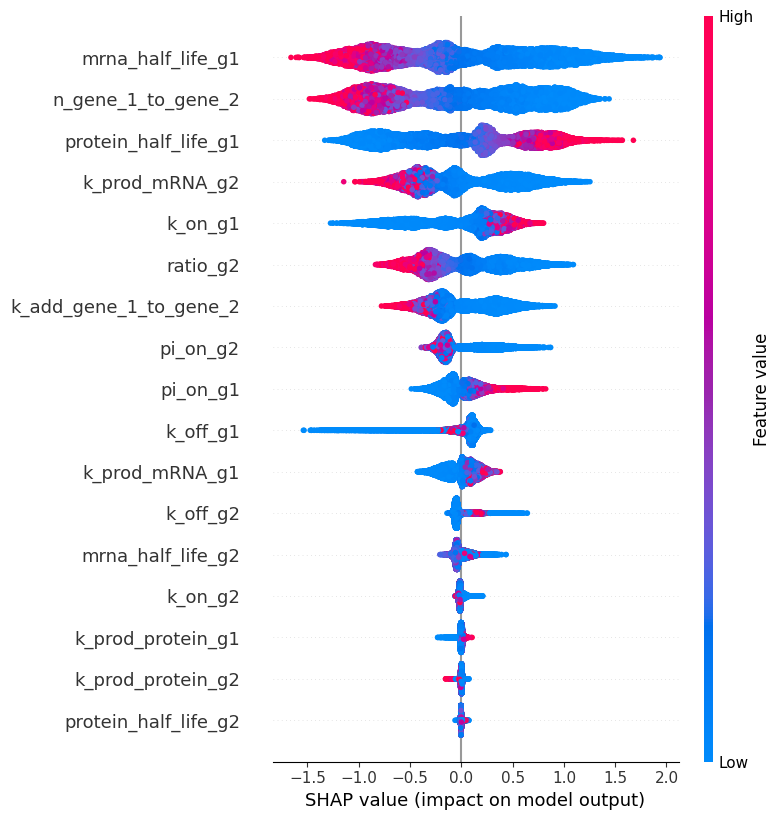

In [7]:
import shap
booster = model.get_booster()
explainer = shap.TreeExplainer(booster)
shap_values = explainer.shap_values(X)
shap.summary_plot(shap_values, X)


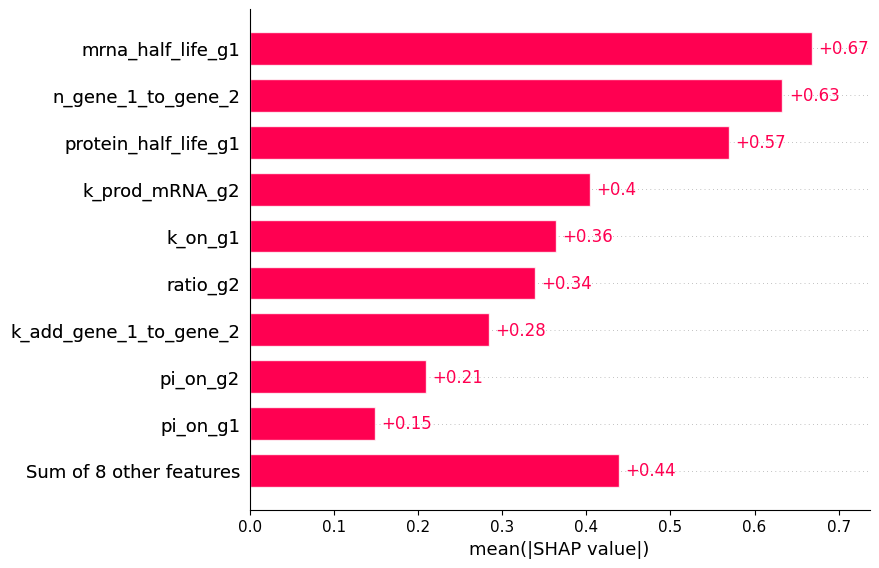

In [8]:
import shap
explainer = shap.explainers.Tree(model.get_booster())
shap_values = explainer(X)
shap.plots.bar(shap_values)


              precision    recall  f1-score   support

           0       0.82      0.77      0.79      2579
           1       0.77      0.81      0.79      2420

    accuracy                           0.79      4999
   macro avg       0.79      0.79      0.79      4999
weighted avg       0.79      0.79      0.79      4999



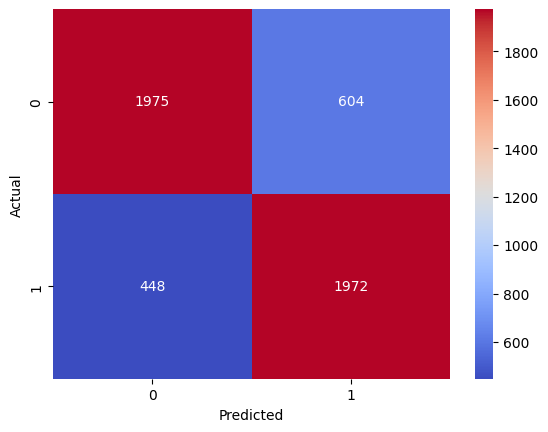



Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.



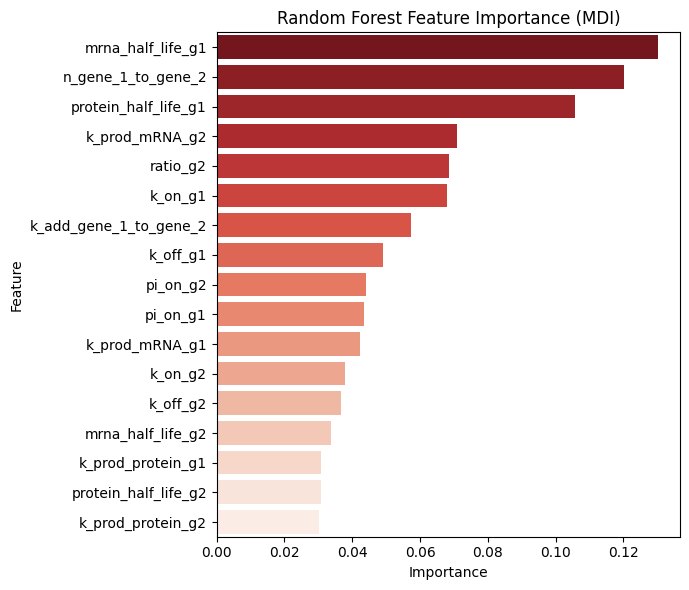

In [9]:
# %% Imports
import pandas as pd
import numpy as np
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns

X = merged.drop(columns=["pair_id", "significant", "corr_gene_gene_gene_1_mRNA_gene_2_mRNA_t1_t20", "ratio_g1"])
y = merged["significant"]


# %% Split and fit
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

rf = RandomForestClassifier(
    n_estimators=300,
    max_depth=None,
    min_samples_split=5,
    min_samples_leaf=3,
    random_state=42,
    n_jobs=-1,
    class_weight="balanced_subsample"
)
rf.fit(X_train, y_train)

# %% Evaluate
y_pred = rf.predict(X_test)
print(classification_report(y_test, y_pred))
sns.heatmap(confusion_matrix(y_test, y_pred), annot=True, fmt="d", cmap="coolwarm")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

# %% Feature importance (mean decrease impurity)
importances = pd.DataFrame({
    "Feature": X.columns,
    "Importance": rf.feature_importances_
}).sort_values("Importance", ascending=False)

plt.figure(figsize=(7,6))
sns.barplot(data=importances.head(20), x="Importance", y="Feature", palette="Reds_r")
plt.title("Random Forest Feature Importance (MDI)")
plt.tight_layout()
plt.show()


In [19]:
import numpy as np
import pandas as pd

def count_feature_depths_rf(rf_model, feature_names, max_depth=2):
    """
    Count how often each feature is used in the top few levels (<= max_depth)
    of every tree in a scikit-learn RandomForest.
    Lower depth = 'easier' / more decisive feature.
    """
    counts = {name: 0 for name in feature_names}

    for est in rf_model.estimators_:
        tree = est.tree_
        features = tree.feature
        children_left, children_right = tree.children_left, tree.children_right

        # --- compute depth of each node using BFS ---
        node_depth = np.zeros(tree.node_count, dtype=int)
        stack = [(0, 0)]  # (node_id, depth)
        while stack:
            node_id, depth = stack.pop()
            node_depth[node_id] = depth
            left, right = children_left[node_id], children_right[node_id]
            if left != -1 and right != -1:  # not a leaf
                stack.append((left, depth + 1))
                stack.append((right, depth + 1))

        # --- count features used in top layers ---
        for node_id, f_idx in enumerate(features):
            if f_idx >= 0 and node_depth[node_id] <= max_depth:
                counts[feature_names[f_idx]] += 1

    df = pd.DataFrame.from_dict(counts, orient="index", columns=["count"])
    df["fraction"] = df["count"] / df["count"].sum()
    df = df.sort_values("count", ascending=False)
    return df

# Example usage
df_top = count_feature_depths_rf(rf, X.columns, max_depth=3)
print(df_top.head(10))


                        count  fraction
mrna_half_life_g1         674  0.149778
protein_half_life_g1      637  0.141556
n_gene_1_to_gene_2        618  0.137333
k_on_g1                   442  0.098222
ratio_g2                  436  0.096889
k_prod_mRNA_g2            400  0.088889
k_add_gene_1_to_gene_2    386  0.085778
k_off_g1                  320  0.071111
pi_on_g2                  168  0.037333
k_on_g2                   132  0.029333


In [35]:
import shap
explainer = shap.TreeExplainer(rf)
shap_values = explainer.shap_values(X)
shap.summary_plot(shap_values[1], X, plot_type="bar")
